In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv("results_all_20260227_185229.csv")
df

,rule,d,n,p,mu_star,nD_star,nI_star,PoA,calc_time_sec
0,ps,3,3,0.05,0.094737,1,3,1.285500,8.890269
1,ps,3,3,0.10,0.156842,2,3,1.583337,9.469573
2,ps,3,3,0.15,0.208421,2,3,1.895101,10.708798
3,ps,3,3,0.20,0.244211,1,3,2.221850,10.714456
4,ps,3,3,0.25,0.270526,1,3,2.564542,11.188367
...,...,...,...,...,...,...,...,...,...
355,sv,5,10,0.80,0.689436,5,1,536.293975,1369.491115
356,sv,5,10,0.85,0.694699,10,8,652.390562,1219.760755
357,sv,5,10,0.90,0.694699,8,9,786.727143,1162.537059
358,sv,5,10,0.95,0.705226,9,3,941.350351,894.441539


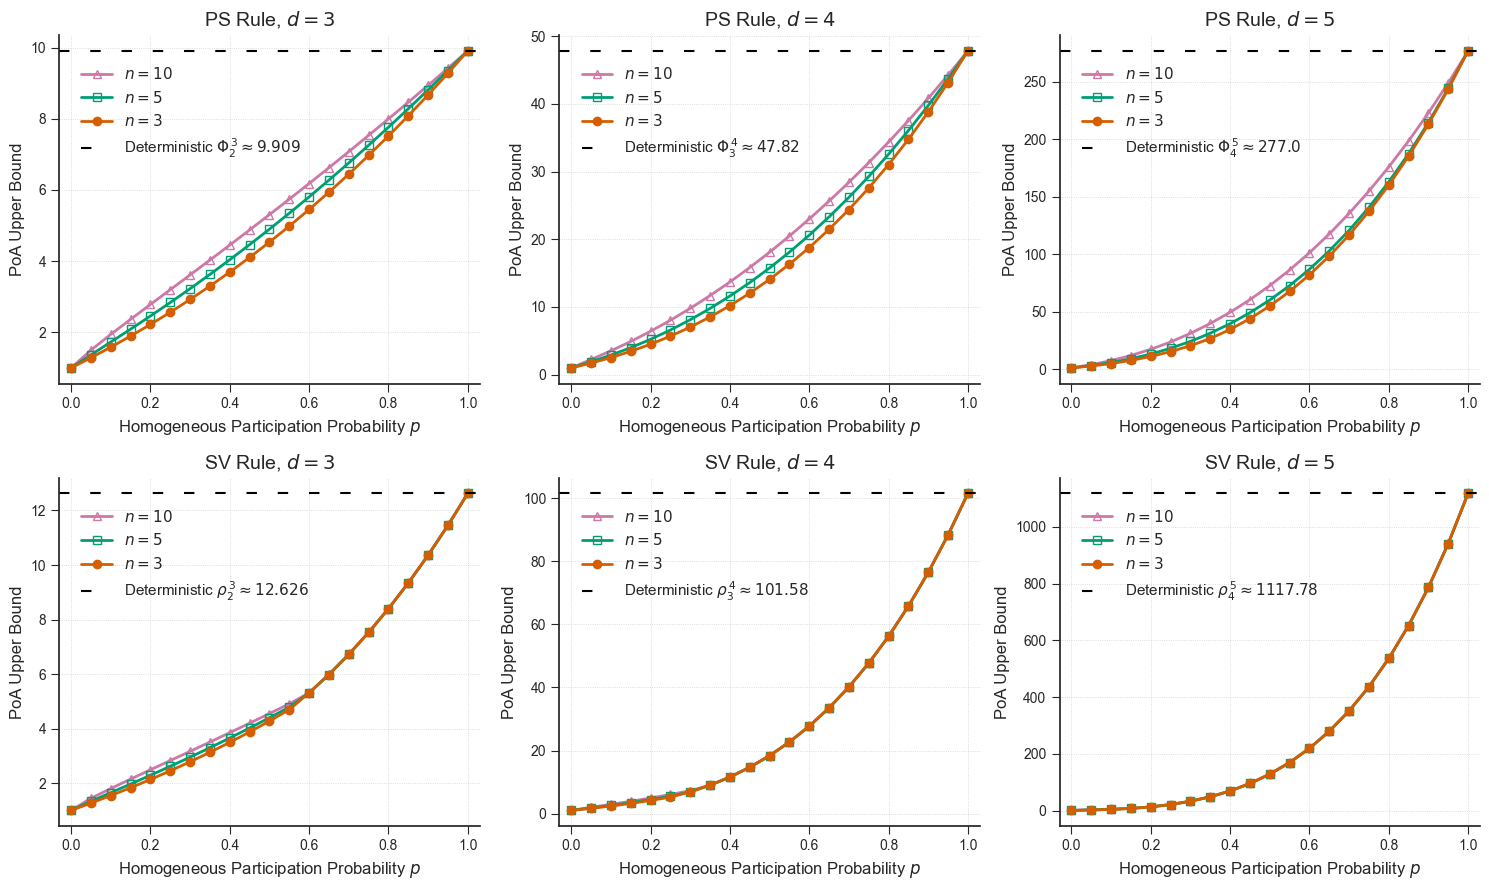

In [64]:
plt.style.use("seaborn-v0_8-ticks")

COLORS = {
    3: "#D55E00",   
    5: "#009E73",   
    10: "#CC79A7",  
    "limit": "black"
}

MARKERS = {3: "o", 5: "s", 10: "^"}

LIMITS = {
    "ps": {3: 9.909, 4: 47.82, 5: 277.0},
    "sv": {3: 12.626, 4: 101.58, 5: 1117.78}
}

# 3. Create 2x3 Subplots (Rows: PS/SV, Columns: d=3,4,5)
fig, axs = plt.subplots(2, 3, figsize=(15, 9))
rules = ["ps", "sv"]
degrees = [3, 4, 5]

for i, rule in enumerate(rules):
    for j, d in enumerate(degrees):
        ax = axs[i, j]
        df_sub = df[(df["rule"] == rule) & (df["d"] == d)]
        
        for n in [10, 5, 3]: 
            data = df_sub[df_sub["n"] == n].sort_values("p")
            if data.empty:
                continue
            
            # Manually inject the p=0, PoA=1 theoretical limit at the beginning
            p_vals = [0.0] + data["p"].tolist()
            poa_vals = [1.0] + data["PoA"].tolist()
            
            f_style = "none" if n != 3 else "full"
            
            ax.plot(p_vals, poa_vals,
                    label=f"$n={n}$",
                    color=COLORS[n],
                    marker=MARKERS[n],
                    markersize=6,
                    linewidth=2,
                    fillstyle=f_style) 
        
        limit_val = LIMITS[rule][d]
        r = d - 1
        if rule == "ps":
            limit_label = rf"Deterministic $\Phi_{r}^{{\,{r+1}}} \approx {limit_val}$"
        else:
            limit_label = rf"Deterministic $\rho_{r}^{{\,{r+1}}} \approx {limit_val}$"
            
        ax.axhline(y=limit_val, color=COLORS["limit"], linestyle=(0, (5, 10)), 
                   linewidth=1.5, label=limit_label)

        ax.set_xlabel(r"Homogeneous Participation Probability $p$", fontsize=12)
        ax.set_ylabel(r"PoA Upper Bound", fontsize=12)
        ax.set_title(f"{rule.upper()} Rule, $d={d}$", fontsize=14)
        ax.grid(True, which="both", linestyle=":", linewidth=0.6, color="lightgray")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
        ax.set_xticks(np.linspace(0, 1, 6))
        # Slight negative offset to ensure the p=0 marker isn't clipped
        ax.set_xlim(-0.03, 1.03) 
        
        ax.legend(fontsize=11, loc="upper left", bbox_to_anchor=(0.02, 0.95))

fig.tight_layout()
plt.savefig("poa_bounds_higher.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [65]:
rules = ["ps", "sv"]
degrees = [3, 4, 5]
n_values = [3, 5, 10]

latex = []
latex.append(r"\begin{table}[htbp]")
latex.append(r"\centering")
latex.append(r"\scriptsize")
latex.append(r"\renewcommand{\arraystretch}{1.15}")
latex.append(r"\setlength{\tabcolsep}{6pt}")
latex.append(r"\caption{Computational runtime and worst case configuration distribution.}")
latex.append(r"\label{tab:poa_higher_stats}")
latex.append(r"\begin{tabular}{ccc rr cccc}")
latex.append(r"\toprule")
latex.append(r"& & & \multicolumn{2}{c}{Runtime (s)} & \multicolumn{4}{c}{Worst Case Frequency (\%)} \\")
latex.append(r"\cmidrule(lr){4-5} \cmidrule(lr){6-9}")
latex.append(r"Rule & $d$ & $n$ & Mean & Max & $n_I^\star=n$ & $n_I^\star \le n/2$ & $n_D^\star=n$ & $n_D^\star \le n/2$ \\")
latex.append(r"\midrule")

for r_idx, rule in enumerate(rules):
    for d_idx, d in enumerate(degrees):
        for n_idx, n in enumerate(n_values):
            sub = df[(df["rule"] == rule) & (df["d"] == d) & (df["n"] == n)]
            if len(sub) == 0:
                continue
            
            mean_t = int(round(sub["calc_time_sec"].mean()))
            max_t = int(round(sub["calc_time_sec"].max()))
            
            nI_full = int(round((sub["nI_star"] == sub["n"]).mean() * 100))
            nI_small = int(round((sub["nI_star"] <= sub["n"] / 2).mean() * 100))
            nD_full = int(round((sub["nD_star"] == sub["n"]).mean() * 100))
            nD_small = int(round((sub["nD_star"] <= sub["n"] / 2).mean() * 100))
            
            col1 = rule.upper() if d_idx == 0 and n_idx == 0 else ""
            col2 = str(d) if n_idx == 0 else ""
            
            row = f"{col1} & {col2} & {n} & {mean_t} & {max_t} & {nI_full}\\% & {nI_small}\\% & {nD_full}\\% & {nD_small}\\% \\\\"
            latex.append(row)
        
        if d != degrees[-1]:
            latex.append(r"\addlinespace")
            
    if rule != rules[-1]:
        latex.append(r"\midrule")

latex.append(r"\bottomrule")
latex.append(r"\end{tabular}")
latex.append(r"\end{table}")

print("\n".join(latex))

\begin{table}[htbp]
\centering
\scriptsize
\renewcommand{\arraystretch}{1.15}
\setlength{\tabcolsep}{6pt}
\caption{Computational runtime and worst case configuration distribution.}
\label{tab:poa_higher_stats}
\begin{tabular}{ccc rr cccc}
\toprule
& & & \multicolumn{2}{c}{Runtime (s)} & \multicolumn{4}{c}{Worst Case Frequency (\%)} \\
\cmidrule(lr){4-5} \cmidrule(lr){6-9}
Rule & $d$ & $n$ & Mean & Max & $n_I^\star=n$ & $n_I^\star \le n/2$ & $n_D^\star=n$ & $n_D^\star \le n/2$ \\
\midrule
PS & 3 & 3 & 13 & 25 & 95\% & 5\% & 30\% & 30\% \\
 &  & 5 & 114 & 162 & 95\% & 5\% & 30\% & 25\% \\
 &  & 10 & 1272 & 1832 & 95\% & 5\% & 5\% & 50\% \\
\addlinespace
 & 4 & 3 & 51 & 70 & 95\% & 0\% & 35\% & 25\% \\
 &  & 5 & 324 & 403 & 95\% & 5\% & 15\% & 40\% \\
 &  & 10 & 2756 & 3597 & 95\% & 0\% & 0\% & 50\% \\
\addlinespace
 & 5 & 3 & 164 & 360 & 95\% & 5\% & 35\% & 30\% \\
 &  & 5 & 1553 & 2596 & 95\% & 5\% & 10\% & 35\% \\
 &  & 10 & 12217 & 18582 & 95\% & 5\% & 0\% & 50\% \\
\midrule
SV & 3 & 

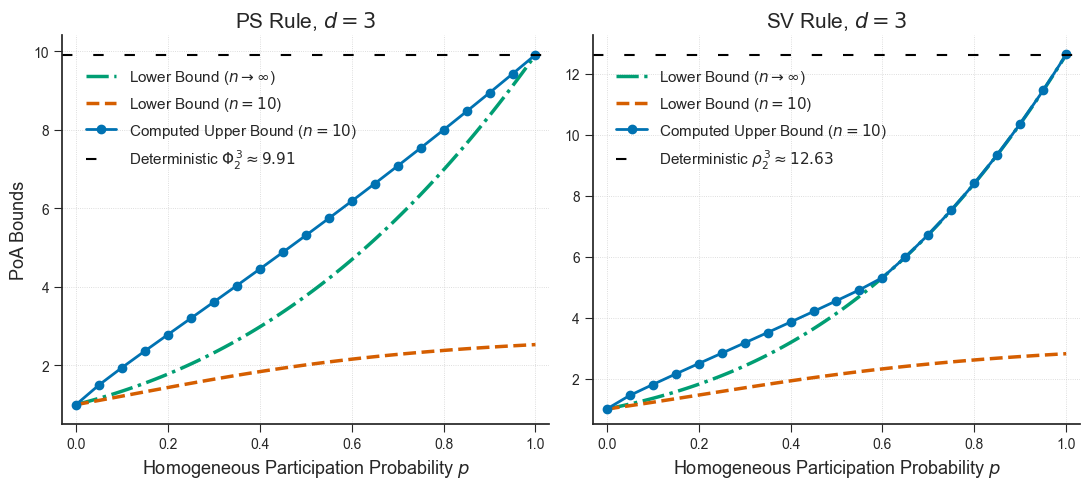

In [66]:
from scipy.optimize import root_scalar
plt.style.use("seaborn-v0_8-ticks")

COLORS = {
    "ub": "#0072B2",       # Blue for Upper Bound (n=10)
    "lb": "#D55E00",       # Orange for Lower Bound (n=10)
    "limit_n": "#009E73",  # Green for Asymptotic Lower Bound (n->inf)
    "limit_det": "black"   # Black for Deterministic Limit (p=1)
}

# --- Balance Equations for Delta(p) ---
def A_sv(delta, p, d):
    return (1 - p) + (p / 2) * (1 + (1 + delta)**d - delta**d)

def A_ps(delta, p, d):
    return (1 - p) + p * (1 + delta)**(d - 1)

def get_delta_sv(p, d):
    if p == 0: return 1.0 # Trivial limit
    def eq(delta): return delta**d - A_sv(delta, p, d)
    return root_scalar(eq, bracket=[1.0, 5.0]).root

def get_delta_ps(p, d):
    if p == 0: return 1.0
    def eq(delta): return delta**d - A_ps(delta, p, d)
    return root_scalar(eq, bracket=[1.0, 5.0]).root

# --- Lower Bound Formula ---
def lower_bound_formula(p, n, delta, d):
    num = n * (delta**d)
    den = n - 2 + (1 - p)*(delta**d + 1) + p * ((1 + delta)**d)
    return num / den

# =============================================================================
# 3. Plotting
# =============================================================================
fig, axs = plt.subplots(1, 2, figsize=(11, 5))
rules = ["ps", "sv"]
d = 3
n = 10
p_grid = np.linspace(0.0, 1.0, 100) # Start exactly at 0

for i, rule in enumerate(rules):
    ax = axs[i]
    
    # Pre-compute Delta(p) array
    if rule == "ps":
        deltas = np.array([get_delta_ps(p, d) for p in p_grid])
        det_limit = get_delta_ps(1.0, d)**d
        limit_label = rf"Deterministic $\Phi_2^{{\,3}} \approx {det_limit:.2f}$"
    else:
        deltas = np.array([get_delta_sv(p, d) for p in p_grid])
        det_limit = get_delta_sv(1.0, d)**d
        limit_label = rf"Deterministic $\rho_2^{{\,3}} \approx {det_limit:.2f}$"

    # 1. Plot Asymptotic Lower Bound (n -> infinity), which is just delta(p)^d
    lb_inf = deltas**d
    ax.plot(p_grid, lb_inf, 
            label=r"Lower Bound ($n \to \infty$)", 
            color=COLORS["limit_n"], linewidth=2.5, linestyle="-.")

    # 2. Plot Analytic Lower Bound (n=10)
    lb_10 = lower_bound_formula(p_grid, n, deltas, d)
    ax.plot(p_grid, lb_10, 
            label=f"Lower Bound ($n={n}$)", 
            color=COLORS["lb"], linewidth=2.5, linestyle="--")

    # 3. Plot QCQP Upper Bound (n=10, Data)
    data = df[(df["rule"] == rule) & (df["d"] == d) & (df["n"] == n)].sort_values("p")
    if not data.empty:
        # Manually inject p=0, PoA=1
        p_vals = [0.0] + data["p"].tolist()
        poa_vals = [1.0] + data["PoA"].tolist()
        ax.plot(p_vals, poa_vals, 
                label=f"Computed Upper Bound ($n={n}$)", 
                color=COLORS["ub"], marker="o", markersize=6, linewidth=2, linestyle="-")

    # 4. Plot Deterministic Limit at p=1 (Horizontal Line)
    ax.axhline(y=det_limit, color=COLORS["limit_det"], linestyle=(0, (5, 10)), 
               linewidth=1.5, label=limit_label)

    # Aesthetics
    ax.set_xlabel("Homogeneous Participation Probability $p$", fontsize=13)
    if i == 0:
        ax.set_ylabel("PoA Bounds", fontsize=13)
        
    ax.set_title(f"{rule.upper()} Rule, $d={d}$", fontsize=15)
    ax.grid(True, which="both", linestyle=":", linewidth=0.6, color="lightgray")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_xlim(-0.03, 1.03)
    
    ax.set_ylim(0.5, det_limit * 1.05)
    
    ax.legend(fontsize=11, loc="upper left", bbox_to_anchor=(0.02, 0.95))

fig.tight_layout()
plt.savefig("poa_bounds_d3_n10_ub_lb_homo.pdf", format="pdf", bbox_inches="tight")
plt.show()

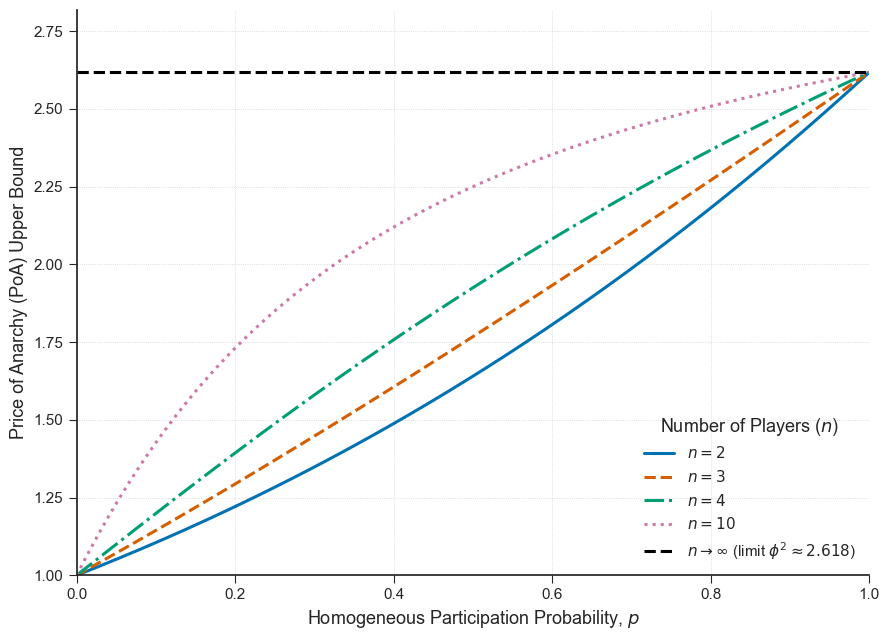

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import math

# =============================================================================
# 1. Core Mathematical Functions
# =============================================================================
def C_func(p, n):
    """Calculates the C(p, n) term from the theorem for n >= 2."""
    if n < 2:
        # Return an array of NaNs with the same shape as p
        return np.full_like(p, np.nan)
        
    m1 = math.floor(n / 2)
    m2 = math.ceil(n / 2)
    
    numerator = p**2
    denominator = 4 * (p + (1 - p) / m1) * (p + (1 - p) / m2)
    
    # Avoid division by zero when p=0
    # The limit as p->0 is 0, so we can safely return 0
    return np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)

def PoA_Hom_func(p, n):
    """Calculates the Price of Anarchy, PoA_Hom(p, n)."""
    C_val = C_func(p, n)
    # The PoA is 1 when C is NaN (e.g., n<2) or p=0
    result = (np.sqrt(C_val) + np.sqrt(C_val + 1))**2
    result[p == 0] = 1.0
    return result

# =============================================================================
# 2. Plotting Configuration (Aesthetically Refined)
# =============================================================================
# Use a clean, minimalist style suitable for academic papers
plt.style.use('seaborn-v0_8-ticks')
fig, ax = plt.subplots(figsize=(9, 6.5)) # Adjusted for a good aspect ratio

# Define a professional, colorblind-friendly color palette
COLORS = {
    2: '#0072B2',    # Blue
    3: '#D55E00',   # Burnt Orange
    4: '#009E73',   # Teal Green
    10: '#CC79A7',  # Reddish Purple
    'limit': 'black'
}
LINESTYLES = {
    2: '-',
    3: '--',
    4: '-.',
    10: ':',
    'limit': (0, (5, 10)) # Loosely dashed for the limit
}

# =============================================================================
# 3. Data Generation
# =============================================================================
p_values = np.linspace(0.0, 1.0, 400) 
n_values_to_plot = [2, 3, 4, 10]

# =============================================================================
# 4. Plotting Elements
# =============================================================================
# Plot a curve for each specified value of n
for n in n_values_to_plot:
    poa_values = PoA_Hom_func(p_values, n)
    ax.plot(p_values, poa_values,
            label=f'$n={n}$',
            color=COLORS.get(n, 'gray'),
            linestyle=LINESTYLES.get(n, '-'),
            lw=2.2)

# Add the theoretical limit line for phi^2 (as n -> infinity)
phi = (1 + np.sqrt(5)) / 2
phi_squared = phi**2
ax.axhline(y=phi_squared, color=COLORS['limit'], linestyle='--', linewidth=2.2, 
           label=r'$n \to \infty$ (limit $\phi^2 \approx 2.618$)')

# --- Labels, Title, and Ticks ---
ax.set_xlabel(r'Homogeneous Participation Probability, $p$', fontsize=13)
ax.set_ylabel(r'Price of Anarchy (PoA) Upper Bound', fontsize=13)
# ax.set_title(r'PoA for Homogeneous SWCG with Quadratic Costs', fontsize=16, pad=15)
ax.tick_params(axis='both', which='major', labelsize=11)

# --- Legend, Grid, and Spines ---
ax.legend(title='Number of Players ($n$)', fontsize=11, title_fontsize=13)
ax.grid(True, which='both', linestyle=':', linewidth=0.6, color='lightgray')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Axis Limits ---
ax.set_xlim(0, 1)
# Start y-axis from 1 as PoA is always >= 1
ax.set_ylim(1, phi_squared + 0.2) 

# Final layout adjustment
fig.tight_layout()
plt.savefig("poa_upper_bounds_homo.pdf", format="pdf", bbox_inches="tight")
plt.show()


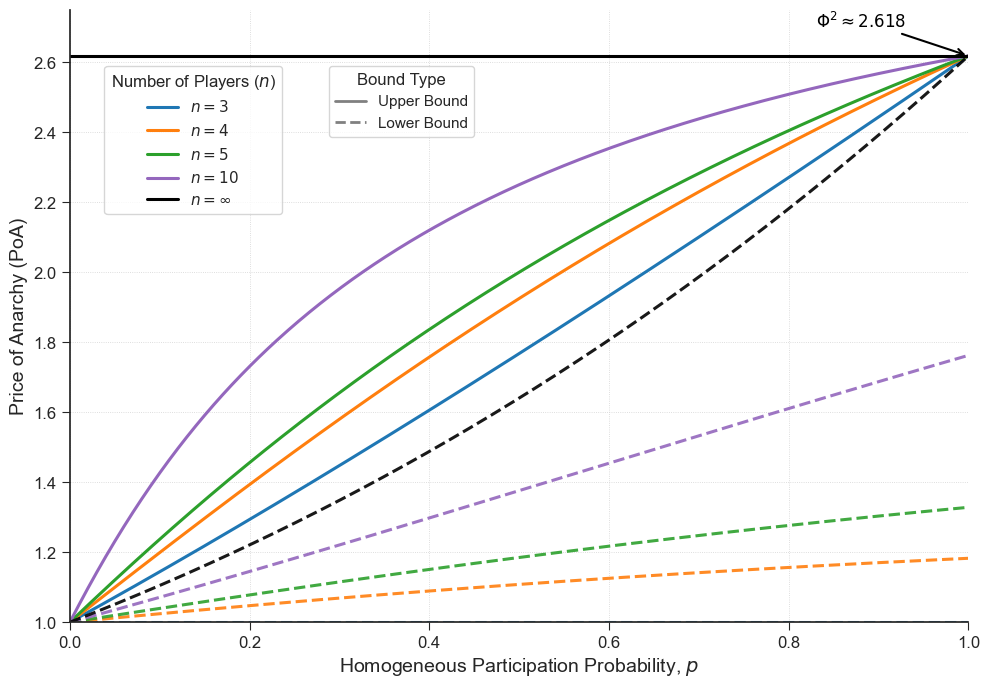

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.lines import Line2D

# 1. Core Mathematical Functions
def C_func(p, n):
    if n == np.inf:
        return np.full_like(p, 0.25)
        
    m1 = math.floor(n / 2)
    m2 = math.ceil(n / 2)
    
    numerator = p**2
    denom_factor1 = p + (1 - p) / m1
    denom_factor2 = p + (1 - p) / m2
    denominator = 4 * denom_factor1 * denom_factor2
    
    return np.divide(numerator, denominator, out=np.zeros_like(p), where=denominator!=0)

def PoA_Hom_UB(p, n):
    C_val = C_func(p, n)
    return (np.sqrt(C_val) + np.sqrt(C_val + 1))**2

def c_p_func(p):
    return (p**2 + p * np.sqrt(p**2 + 4)) / 2

def PoA_Hom_LB(p, n):
    cp = c_p_func(p)
    if n == np.inf:
        return 1 + cp
    else:
        return (n + n * cp) / (n + 3 * cp)

# 2. Plotting Configuration
plt.style.use('seaborn-v0_8-ticks')
fig, ax = plt.subplots(figsize=(10, 7))

colors_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', 'black'] 
n_values = [3, 4, 5, 10, np.inf]
n_labels = ['3', '4', '5', '10', r'\infty']
COLOR_MAP = {n: color for n, color in zip(n_values, colors_list)}

# 3. Data Generation
p_values = np.linspace(0.0, 1.0, 500)

for n, label_n in zip(n_values, n_labels):
    color = COLOR_MAP[n]
    
    ub_values = PoA_Hom_UB(p_values, n)
    ax.plot(p_values, ub_values, 
            linestyle='-', color=color, linewidth=2.2, 
            label=f'$n={label_n}$')
    
    lb_values = PoA_Hom_LB(p_values, n)
    ax.plot(p_values, lb_values, 
            linestyle='--', color=color, linewidth=2.2, alpha=0.9)

# 4. Side-by-Side Legends
handles, labels = ax.get_legend_handles_labels()

# Legend 1: Number of Players (Left)
legend1 = ax.legend(handles, labels, 
                    title='Number of Players ($n$)', 
                    loc='upper left',            
                    bbox_to_anchor=(0.03, 0.92), # Shifted down slightly
                    fontsize=11, title_fontsize=12, frameon=True)

# Legend 2: Bound Type (Right)
line_solid = Line2D([0], [0], color='gray', linewidth=2, linestyle='-')
line_dashed = Line2D([0], [0], color='gray', linewidth=2, linestyle='--')

legend2 = ax.legend([line_solid, line_dashed], ['Upper Bound', 'Lower Bound'], 
                    title='Bound Type', 
                    loc='upper left',            
                    bbox_to_anchor=(0.28, 0.92), # Shifted right to sit next to legend1
                    fontsize=11, title_fontsize=12, frameon=True)

# Add Legend 1 back to the plot (Matplotlib removes the first when a second is created)
ax.add_artist(legend1)

# 5. Aesthetics and Formatting
ax.set_xlabel(r'Homogeneous Participation Probability, $p$', fontsize=14)
ax.set_ylabel(r'Price of Anarchy (PoA)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)

ax.grid(True, which='both', linestyle=':', linewidth=0.6, color='lightgray')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim(0, 1)
ax.set_ylim(1, 2.75) 

# Add asymptotic limit annotation
phi_sq = ((1 + np.sqrt(5)) / 2)**2
ax.annotate(r'$\Phi^2 \approx 2.618$', xy=(1, phi_sq), xytext=(0.88, 2.7),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5), 
            fontsize=12, ha='center', color='black')

plt.tight_layout()
plt.savefig('poa_bounds_ub_lb_homo.pdf', format='pdf', bbox_inches='tight')
plt.show()

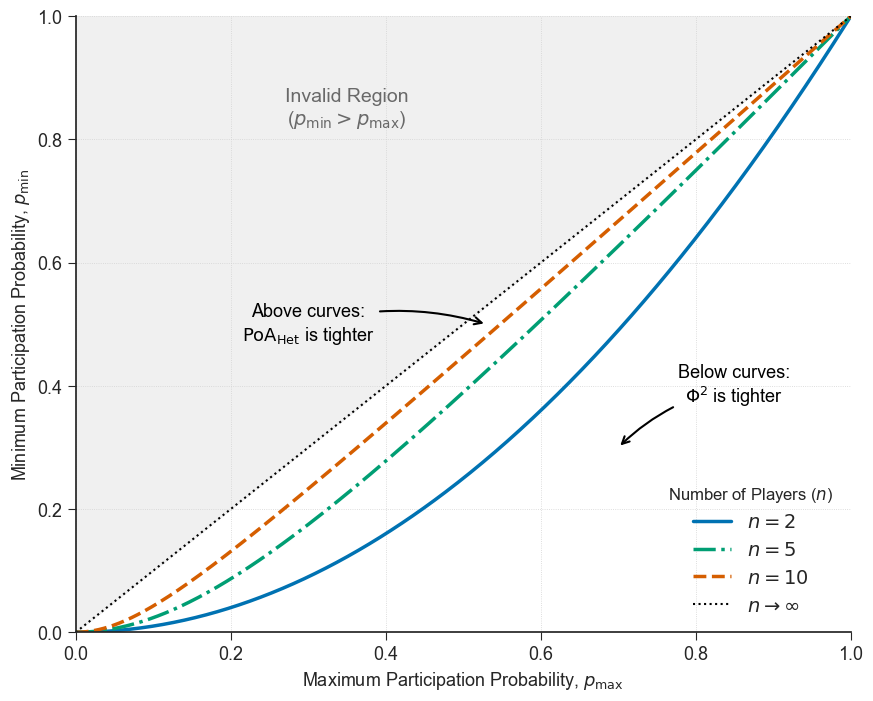

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# =============================================================================
# 1. Core Mathematical Functions
# =============================================================================
def f(p_min, n):
    """
    Calculates the right-hand side of the critical inequality:
    f(p_min) = (p_min^2 + p_min(1-p_min)/floor(n/2)) * (p_min^2 + p_min(1-p_min)/ceil(n/2))
    """
    if n < 2:
        return np.inf
    m1 = int(np.floor(n / 2))
    m2 = int(np.ceil(n / 2))
    # Safeguard for n=1 case, although our analysis assumes n>=2
    m1 = max(m1, 1)
    
    term1 = p_min**2 + p_min * (1 - p_min) / m1
    term2 = p_min**2 + p_min * (1 - p_min) / m2
    return term1 * term2

def solve_for_critical_p_min(p_max, n):
    """
    Numerically solves f(p_min, n) = p_max^4 for p_min.
    This gives the critical boundary value p_min* on the interval [0, p_max].
    """
    # Define the objective function whose root we want to find
    objective = lambda p_min: f(p_min, n) - p_max**4

    # If f(p_max) < p_max^4, the critical boundary is outside the feasible region [0, p_max].
    # In this case, for all p_min <= p_max, PoA_Het is tighter. The "boundary" is effectively p_min = p_max.
    if objective(p_max) < 0:
        return p_max

    # Use a robust numerical solver (Brent's method) to find the root.
    try:
        # The solver finds p_min such that objective(p_min) = 0.
        return brentq(objective, 0.0, p_max)
    except ValueError:
        # This can happen at the edges (e.g., p_max=0) where no valid interval exists.
        return np.nan

# =============================================================================
# 2. Plotting Configuration (Aesthetically Refined)
# =============================================================================
# Use a clean, minimalist style suitable for academic papers
plt.style.use('seaborn-v0_8-ticks')
fig, ax = plt.subplots(figsize=(10, 8))

# Define a professional, colorblind-friendly color palette
COLORS = {
    2: '#0072B2',    # Blue
    10: '#D55E00',   # Burnt Orange
    5: '#009E73',   # Teal Green
    'limit': 'black',
    'invalid': '#F0F0F0' # Light Grey
}
LINESTYLES = {
    2: '-',
    10: '--',
    5: '-.',
    'limit': ':'
}

# =============================================================================
# 3. Data Generation
# =============================================================================
p_max_values = np.linspace(0.0, 1.0, 500)
n_values_to_plot = [2, 5, 10]

curves = {}
for n in n_values_to_plot:
    y_values = np.array([solve_for_critical_p_min(px, n) for px in p_max_values])
    curves[n] = y_values

# =============================================================================
# 4. Plotting Elements
# =============================================================================
# Set plot limits and aspect ratio first
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
# ax.set_aspect('equal', adjustable='box')
ax.tick_params(axis='both', which='major', labelsize=13)

# --- Fill the Invalid Region ---
# A subtle light grey fill is less distracting than hatches
ax.fill_between(p_max_values, p_max_values, 1, color=COLORS['invalid'], zorder=-1, label='_nolegend_')

# --- Plot Curves ---
for n in n_values_to_plot:
    ax.plot(p_max_values, curves[n], color=COLORS[n], linestyle=LINESTYLES[n],
            lw=2.5, label=f'$n = {n}$')

# Plot the n -> infinity limit
ax.plot([0, 1], [0, 1], color=COLORS['limit'], linestyle=LINESTYLES['limit'],
        lw=1.5, label=r'$n \to \infty$')

# --- Labels, Title, and Annotations ---
ax.set_xlabel(r'Maximum Participation Probability, $p_{\max}$', fontsize=13)
ax.set_ylabel(r'Minimum Participation Probability, $p_{\min}$', fontsize=13)
# ax.set_title(r'Phase Diagram for PoA Bound Superiority', fontsize=16, pad=20)

# Use arrows and cleaner text for annotations
ax.annotate("Invalid Region\n" r"($p_{\min} > p_{\max}$)",
            xy=(0.35, 0.85), xycoords="axes fraction",
            ha="center", va="center", color="dimgray", fontsize=14)

ax.annotate(r'Above curves:' '\n' r'$\mathrm{PoA}_{\mathrm{Het}}$ is tighter',
            xy=(0.53, 0.5), xycoords='axes fraction',
            xytext=(0.3, 0.5), textcoords='axes fraction',
            ha='center', va='center', color='black', fontsize=13,
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.15", color='black', lw=1.5))

ax.annotate(r'Below curves:' '\n' r'$\Phi^2$ is tighter',
            xy=(0.7, 0.3), xycoords='axes fraction',
            xytext=(0.85, 0.4), textcoords='axes fraction',
            ha='center', va='center', color='black', fontsize=13,
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.15", color='black', lw=1.5))

# --- Legend and Grid ---
ax.legend(title='Number of Players ($n$)', loc='lower right', fontsize=14, title_fontsize=12)
ax.grid(True, which='both', linestyle=':', linewidth=0.6, color='lightgray')

# Remove top and right spines for a cleaner, modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# fig.tight_layout()
plt.savefig('poa_bounds_ub_valid_heter.pdf', format='pdf', bbox_inches='tight')
plt.show()
